In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import sklearn.metrics as metrics

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [5]:
userInputData = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIG = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 79 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\UserPrevious experiments-preprocessed.json
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 199098 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\Data:Previous experiments-preprocessed.json


In [6]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,1751328000000,1751383639000,1751386484000,2845000,2543000,2543,302000
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,1751414400000,1751470970000,1751472292000,1322000,1000000,1000,322000
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,1751500800000,1751545825000,1751546731000,906000,248000,248,658000
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,1751500800000,1751557900000,1751558351000,451000,88000,88,363000
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,1752019200000,1752087704000,1752089270000,1566000,1056000,1056,510000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,1756166400000,1756213347000,1756214628000,1281000,424000,424,857000
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,1756166400000,1756215406000,1756216384000,978000,317000,317,661000
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,1756166400000,1756225781000,1756228276000,2495000,1171000,1171,1324000
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,1756166400000,1756230988000,1756233200000,2212000,1719000,1719,493000


In [7]:
timeSeriesData_BIG

,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0,0,Id=1:BME680:breathVocEquivalent,1.476941,False,False,1751383639000,0
1,0,0,Id=2:BME680:breathVocEquivalent,1.430472,False,True,1751383639000,0
2,0,1000,Id=1:BME680:breathVocEquivalent,1.473184,False,False,1751383640000,1
3,0,1000,Id=2:BME680:breathVocEquivalent,1.434089,False,False,1751383640000,1
4,0,2000,Id=1:BME680:breathVocEquivalent,1.469428,False,True,1751383641000,2
...,...,...,...,...,...,...,...,...
199093,78,761000,Id=2:BME680:breathVocEquivalent,513.575400,True,True,1756234548000,761
199094,78,761000,Id=0:BME680:breathVocEquivalent,25.242983,True,False,1756234548000,761
199095,78,762000,Id=1:BME680:breathVocEquivalent,81.105730,True,False,1756234549000,762
199096,78,762000,Id=2:BME680:breathVocEquivalent,513.575400,True,False,1756234549000,762


In [8]:
# Convert back to timedelta
timeSeriesData_BIG['timestamp'] = pd.to_timedelta(timeSeriesData_BIG['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIG ["datetime_timestamp"]= timeSeriesData_BIG['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)
# Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}

In [9]:
dict_of_timeseries[0]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.476941,False,False,2025-07-01 15:27:19,0
1,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,1.430472,False,True,2025-07-01 15:27:19,0
2,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.473184,False,False,2025-07-01 15:27:20,1
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,1.434089,False,False,2025-07-01 15:27:20,1
4,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,1.469428,False,True,2025-07-01 15:27:21,2
...,...,...,...,...,...,...,...
5687,0 days 00:47:23,Id=2:BME680:breathVocEquivalent,9.453519,True,False,2025-07-01 16:14:42,2843
5688,0 days 00:47:24,Id=1:BME680:breathVocEquivalent,5.150744,True,False,2025-07-01 16:14:43,2844
5689,0 days 00:47:24,Id=2:BME680:breathVocEquivalent,9.469537,True,True,2025-07-01 16:14:43,2844
5690,0 days 00:47:25,Id=1:BME680:breathVocEquivalent,5.150744,True,False,2025-07-01 16:14:44,2845


In [10]:
columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', ]
columns_timedelta = ['time taken total',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']

userInputData.loc[:,columns_datetime] = userInputData.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputData.loc[:,columns_timedelta] = userInputData.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [11]:
#remove all 
timeSeriesData_BIG_check_Interpolation = timeSeriesData_BIG.copy()
print(timeSeriesData_BIG_check_Interpolation.columns)
timeSeriesData_BIG_check_Interpolation["VOC given real values"] = timeSeriesData_BIG_check_Interpolation["VOC"]
timeSeriesData_BIG_check_Interpolation.loc[timeSeriesData_BIG_check_Interpolation["original_value"]==False,"VOC given real values"] = np.nan
timeSeriesData_BIG_check_Interpolation["original_value_cum_sum"] = \
    timeSeriesData_BIG_check_Interpolation.groupby(["keys","sensors"])["original_value"].transform("cumsum")
#make every second appear of a true given value null also 
mask = (timeSeriesData_BIG_check_Interpolation["original_value"] == True) & (timeSeriesData_BIG_check_Interpolation["original_value_cum_sum"] % 2 == 0)
timeSeriesData_BIG_check_Interpolation.loc[:,"kept to test interpolation"] =timeSeriesData_BIG_check_Interpolation.apply(lambda x: True if ((x["original_value"] == True) & (x["original_value_cum_sum"] % 2 == 1)) else False,axis=1)
timeSeriesData_BIG_check_Interpolation.head(20)

Index(['keys', 'timestamp', 'sensors', 'VOC', 'after_insertion',
       'original_value', 'datetime_timestamp', 'seconds'],
      dtype='object')


,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds,VOC given real values,original_value_cum_sum,kept to test interpolation
0,0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.476941,False,False,2025-07-01 15:27:19,0,NaN,0,False
1,0,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,1.430472,False,True,2025-07-01 15:27:19,0,1.430472,1,True
2,0,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.473184,False,False,2025-07-01 15:27:20,1,NaN,0,False
3,0,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,1.434089,False,False,2025-07-01 15:27:20,1,NaN,1,False
4,0,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,1.469428,False,True,2025-07-01 15:27:21,2,1.469428,1,True
5,0,0 days 00:00:02,Id=2:BME680:breathVocEquivalent,1.437705,False,False,2025-07-01 15:27:21,2,NaN,1,False
6,0,0 days 00:00:03,Id=1:BME680:breathVocEquivalent,1.471700,False,False,2025-07-01 15:27:22,3,NaN,1,False
7,0,0 days 00:00:03,Id=2:BME680:breathVocEquivalent,1.441322,False,True,2025-07-01 15:27:22,3,1.441322,2,False
8,0,0 days 00:00:04,Id=1:BME680:breathVocEquivalent,1.473971,False,False,2025-07-01 15:27:23,4,NaN,1,False
9,0,0 days 00:00:04,Id=2:BME680:breathVocEquivalent,1.444173,False,False,2025-07-01 15:27:23,4,NaN,2,False


In [12]:
# Split back into dict
dict_of_timeseries_inter = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG_check_Interpolation.groupby("keys")}

In [13]:
dict_of_timeseries_inter[2]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds,VOC given real values,original_value_cum_sum,kept to test interpolation
0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,2.110552,False,True,2025-07-03 12:30:25,0,2.110552,1,True
1,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,4.323138,False,True,2025-07-03 12:30:25,0,4.323138,1,True
2,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,2.110852,False,False,2025-07-03 12:30:26,1,NaN,1,False
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,4.321439,False,False,2025-07-03 12:30:26,1,NaN,1,False
4,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,2.111153,False,False,2025-07-03 12:30:27,2,NaN,1,False
...,...,...,...,...,...,...,...,...,...,...
1809,0 days 00:15:04,Id=2:BME680:breathVocEquivalent,29.074413,True,False,2025-07-03 12:45:29,904,NaN,302,False
1810,0 days 00:15:05,Id=1:BME680:breathVocEquivalent,2.092415,True,False,2025-07-03 12:45:30,905,NaN,302,False
1811,0 days 00:15:05,Id=2:BME680:breathVocEquivalent,29.758007,True,False,2025-07-03 12:45:30,905,NaN,302,False
1812,0 days 00:15:06,Id=1:BME680:breathVocEquivalent,2.099104,True,True,2025-07-03 12:45:31,906,2.099104,303,True


In [26]:
def insertColumnsTointerpolation_differences(interpolation_differences,method):
    columns= []
    sensors_names = ["Id=0:BME680:breathVocEquivalent","Id=1:BME680:breathVocEquivalent","Id=2:BME680:breathVocEquivalent"]
    columns.extend(["MSE-" + x +"-"+method for x in sensors_names])
    columns.extend(["MAE-" + x +"-"+method for x in sensors_names])
    columns.extend(["R2-" + x +"-"+method for x in sensors_names])
    for column in columns:
        interpolation_differences[column] = np.nan
    return interpolation_differences

In [43]:
def checkInterpolationMethod(interpolation_differences,method):
    #add the relevant columns to interpolation_differences
    interpolation_differences = insertColumnsTointerpolation_differences(interpolation_differences,method)

    columns_to_keep = ["seconds","sensors","VOC given real values","kept to test interpolation"]
    for index, row in userInputData.iterrows():
        element_df = dict_of_timeseries_inter[index]
        sensors = element_df["sensors"].unique()
        for sensor in sensors:
            mask = (element_df["sensors"] == sensor) & (element_df["VOC given real values"].notna())
            y_original = element_df.loc[mask,columns_to_keep]
            y_original = y_original.reset_index(drop=True)
            y_lacking = element_df.loc[mask,columns_to_keep]
            y_lacking = y_lacking.reset_index(drop=True)
            y_lacking.loc[y_lacking["kept to test interpolation"]==False,"VOC given real values"] = np.nan
            y_lacking["VOC given real values"] = y_lacking["VOC given real values"].interpolate(method = method)
            mse = metrics.mean_squared_error(y_original["VOC given real values"].dropna(), y_lacking["VOC given real values"].dropna())
            column_to_save = "MSE-"+sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mse
            mae = metrics.mean_absolute_error(y_original["VOC given real values"].dropna(), y_lacking["VOC given real values"].dropna())
            column_to_save = "MAE-"+sensor +"-"+method
            interpolation_differences.at[index,column_to_save] = mae
            #R2 = metrics.r2_score(y_original["VOC given real values"].dropna(), y_lacking["VOC given real values"].dropna())
            #column_to_save = "R2-"+sensor +"-"+method
            #interpolation_differences.at[index,column_to_save] = R2
    

In [44]:
interpolation_differences = pd.DataFrame(index = np.arange(userInputData.shape[0]))

checkInterpolationMethod(interpolation_differences,"linear")
checkInterpolationMethod(interpolation_differences,"cubicspline")

In [45]:
interpolation_differences

,MSE-Id=0:BME680:breathVocEquivalent-linear,MSE-Id=1:BME680:breathVocEquivalent-linear,MSE-Id=2:BME680:breathVocEquivalent-linear,MAE-Id=0:BME680:breathVocEquivalent-linear,MAE-Id=1:BME680:breathVocEquivalent-linear,MAE-Id=2:BME680:breathVocEquivalent-linear,R2-Id=0:BME680:breathVocEquivalent-linear,R2-Id=1:BME680:breathVocEquivalent-linear,R2-Id=2:BME680:breathVocEquivalent-linear,MSE-Id=0:BME680:breathVocEquivalent-cubicspline,MSE-Id=1:BME680:breathVocEquivalent-cubicspline,MSE-Id=2:BME680:breathVocEquivalent-cubicspline,MAE-Id=0:BME680:breathVocEquivalent-cubicspline,MAE-Id=1:BME680:breathVocEquivalent-cubicspline,MAE-Id=2:BME680:breathVocEquivalent-cubicspline,R2-Id=0:BME680:breathVocEquivalent-cubicspline,R2-Id=1:BME680:breathVocEquivalent-cubicspline,R2-Id=2:BME680:breathVocEquivalent-cubicspline
0,NaN,0.000040,0.000514,NaN,0.003034,0.010995,NaN,NaN,NaN,NaN,0.000076,0.000550,NaN,0.003246,0.011600,NaN,NaN,NaN
1,NaN,0.000010,0.000005,NaN,0.001426,0.001193,NaN,NaN,NaN,NaN,0.000007,0.000006,NaN,0.001349,0.001274,NaN,NaN,NaN
2,NaN,0.000065,0.004953,NaN,0.004466,0.024207,NaN,NaN,NaN,NaN,0.000069,0.002319,NaN,0.004513,0.019748,NaN,NaN,NaN
3,NaN,0.000014,0.011498,NaN,0.002027,0.046138,NaN,NaN,NaN,NaN,0.000018,0.007721,NaN,0.002220,0.040268,NaN,NaN,NaN
4,NaN,0.000004,0.000017,NaN,0.001072,0.002162,NaN,NaN,NaN,NaN,0.000004,0.000017,NaN,0.001109,0.002210,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,0.000894,0.000152,0.000064,0.014439,0.005241,0.003739,NaN,NaN,NaN,0.000834,0.000120,0.000054,0.013964,0.004580,0.003542,NaN,NaN,NaN
75,0.001558,0.000170,0.000051,0.019849,0.006526,0.003636,NaN,NaN,NaN,0.001538,0.000174,0.000047,0.020001,0.006830,0.003585,NaN,NaN,NaN
76,0.035126,0.271883,1.203000,0.047001,0.088623,0.171044,NaN,NaN,NaN,0.007039,0.037460,0.234289,0.030369,0.047611,0.087951,NaN,NaN,NaN
77,0.000305,0.000811,0.000514,0.009788,0.014003,0.012847,NaN,NaN,NaN,0.000453,0.000598,0.000571,0.010452,0.013174,0.013442,NaN,NaN,NaN


In [46]:
interpolation_differences[["MSE-Id=0:BME680:breathVocEquivalent-linear","MSE-Id=0:BME680:breathVocEquivalent-cubicspline"]]

,MSE-Id=0:BME680:breathVocEquivalent-linear,MSE-Id=0:BME680:breathVocEquivalent-cubicspline
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
74,0.000894,0.000834
75,0.001558,0.001538
76,0.035126,0.007039
77,0.000305,0.000453


<Axes: >

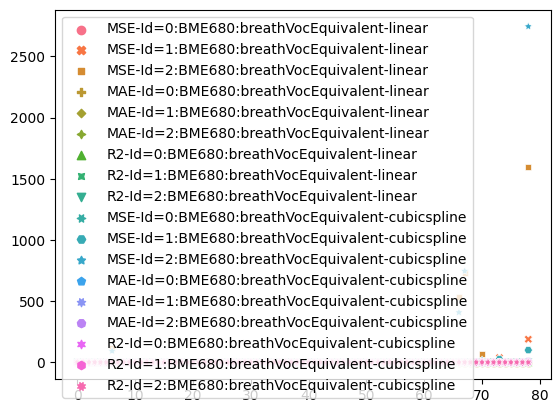

In [42]:
sns.scatterplot(interpolation_differences.columns[interpolation_differences.columns.str.contains("MSE")])

In [ ]:
sns.scatterplot(interpolation_differences.columns[interpolation_differences.columns.str.contains("MAE")])

In [ ]:
sns.scatterplot(interpolation_differences[])